In [1]:
!pip install osmnx geopy

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geopandas-1.0.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached geographiclib-2.0-py3-none-any.whl.metadata (1.4 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.0-py3-none-any.whl (40 kB)
Using cached geopandas-1.0.1-py3-none-any.whl (323 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------ --------- 1.3/1.7 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   -- ------------------------------------- 1.3/19.2 MB 7.4 MB/s eta 0:00:03
   ----- ---------------------------------- 2.6/19.2 MB 6.9 MB/s eta 0:00:03
   --------- ------------------------------ 4.5/19.2 MB 7.2 MB/s eta 0:00:03
   ------------ --------------------------- 6.0/19.2 MB 7.4 MB/s eta 0:00:02
   --------------- ------------------------

In [1]:
import os
import osmnx as ox
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim

In [33]:
class CityMapProcessor:
    def __init__(self, city_name):
        self.city_name = city_name
        self.boundary_data = None
        self.array = None
        self.output_resolution = (2048, 2048)  # Width x Height in pixels
        self.dpi = 200  # Dots per inch
        self.figsize = (self.output_resolution[0] / self.dpi, self.output_resolution[1] / self.dpi)
        self.output_dir = "/buildingfootprints"
        os.makedirs(self.output_dir, exist_ok=True)


    def get_osm_boundary(self):
        # Get the bounding box for the city
        geolocator = Nominatim(user_agent="geoapi", timeout=10)
        try:
            location = geolocator.geocode(self.city_name, exactly_one=True)
            if location:
                bbox = location.raw.get('boundingbox', None)
                if bbox:
                    lat_min, lat_max, lon_min, lon_max = map(float, bbox)
                    self.boundary_data = {
                        "bbox": (lon_min, lat_min, lon_max, lat_max),
                    }
        except Exception as e:
            print(f"Error fetching bbox for {self.city_name}: {e}")

    def save_street_layout(self):
        # Save the street layout as an image
        fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)
        G = ox.graph_from_bbox(self.boundary_data["bbox"], network_type='drive')
        gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
        gdf_edges.plot(ax=ax, color="red", linewidth=0.1, alpha=1)
        minx, miny, maxx, maxy = self.boundary_data["bbox"]
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        street_layout_path = os.path.join(self.output_dir, f"street/{self.city_name}_street_network.png")
        os.makedirs(os.path.dirname(street_layout_path), exist_ok=True)

        if os.path.exists(street_layout_path):
            print(f"Street layout for {self.city_name} already exist. Skipping...")
        else:
            self.save_image(ax, street_layout_path, show= True)
    def save_building_footprints(self):
        # Save building footprints as an image
        fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)
        minx, miny, maxx, maxy = self.boundary_data["bbox"]

        tags = {'building': True}
        geolocator = Nominatim(user_agent="geoapi", timeout=10)
        location = geolocator.geocode(self.city_name, exactly_one=True)
        if not location:
            print(f"Could not get center for {self.city_name}. Skipping buildings.")
            return

        center = (location.latitude, location.longitude)
        buildings = ox.features.features_from_point(center, dist=6000, tags=tags)

        if buildings.empty:
            print(f"No buildings found for {self.city_name}.")
            return

        buildings.plot(ax=ax, color='black', linewidth=0.1, alpha=1)
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

        building_path = os.path.join(self.output_dir, f"buildings/{self.city_name}_building_footprints.png")
        os.makedirs(os.path.dirname(building_path), exist_ok=True)

        if os.path.exists(building_path):
            print(f"Building footprints for {self.city_name} already exist. Skipping...")
        else:
            self.save_image(ax, building_path, show= True)
    def save_image(self, ax, filepath, show=False):
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(filepath, dpi=self.dpi, bbox_inches='tight', pad_inches=0)
        if show:
            plt.show()
        plt.close()


    def process(self):
        try:
            self.get_osm_boundary()
            if self.boundary_data is None:
                print(f"Could not fetch boundary data for {self.city_name}. Skipping...")
                return

            self.save_street_layout()
            self.save_building_footprints()

        except Exception as e:
            print(f"An error occurred while processing {self.city_name}: {e}. Skipping...")

Initializing CityMapProcessor for city: eixample, barcelona


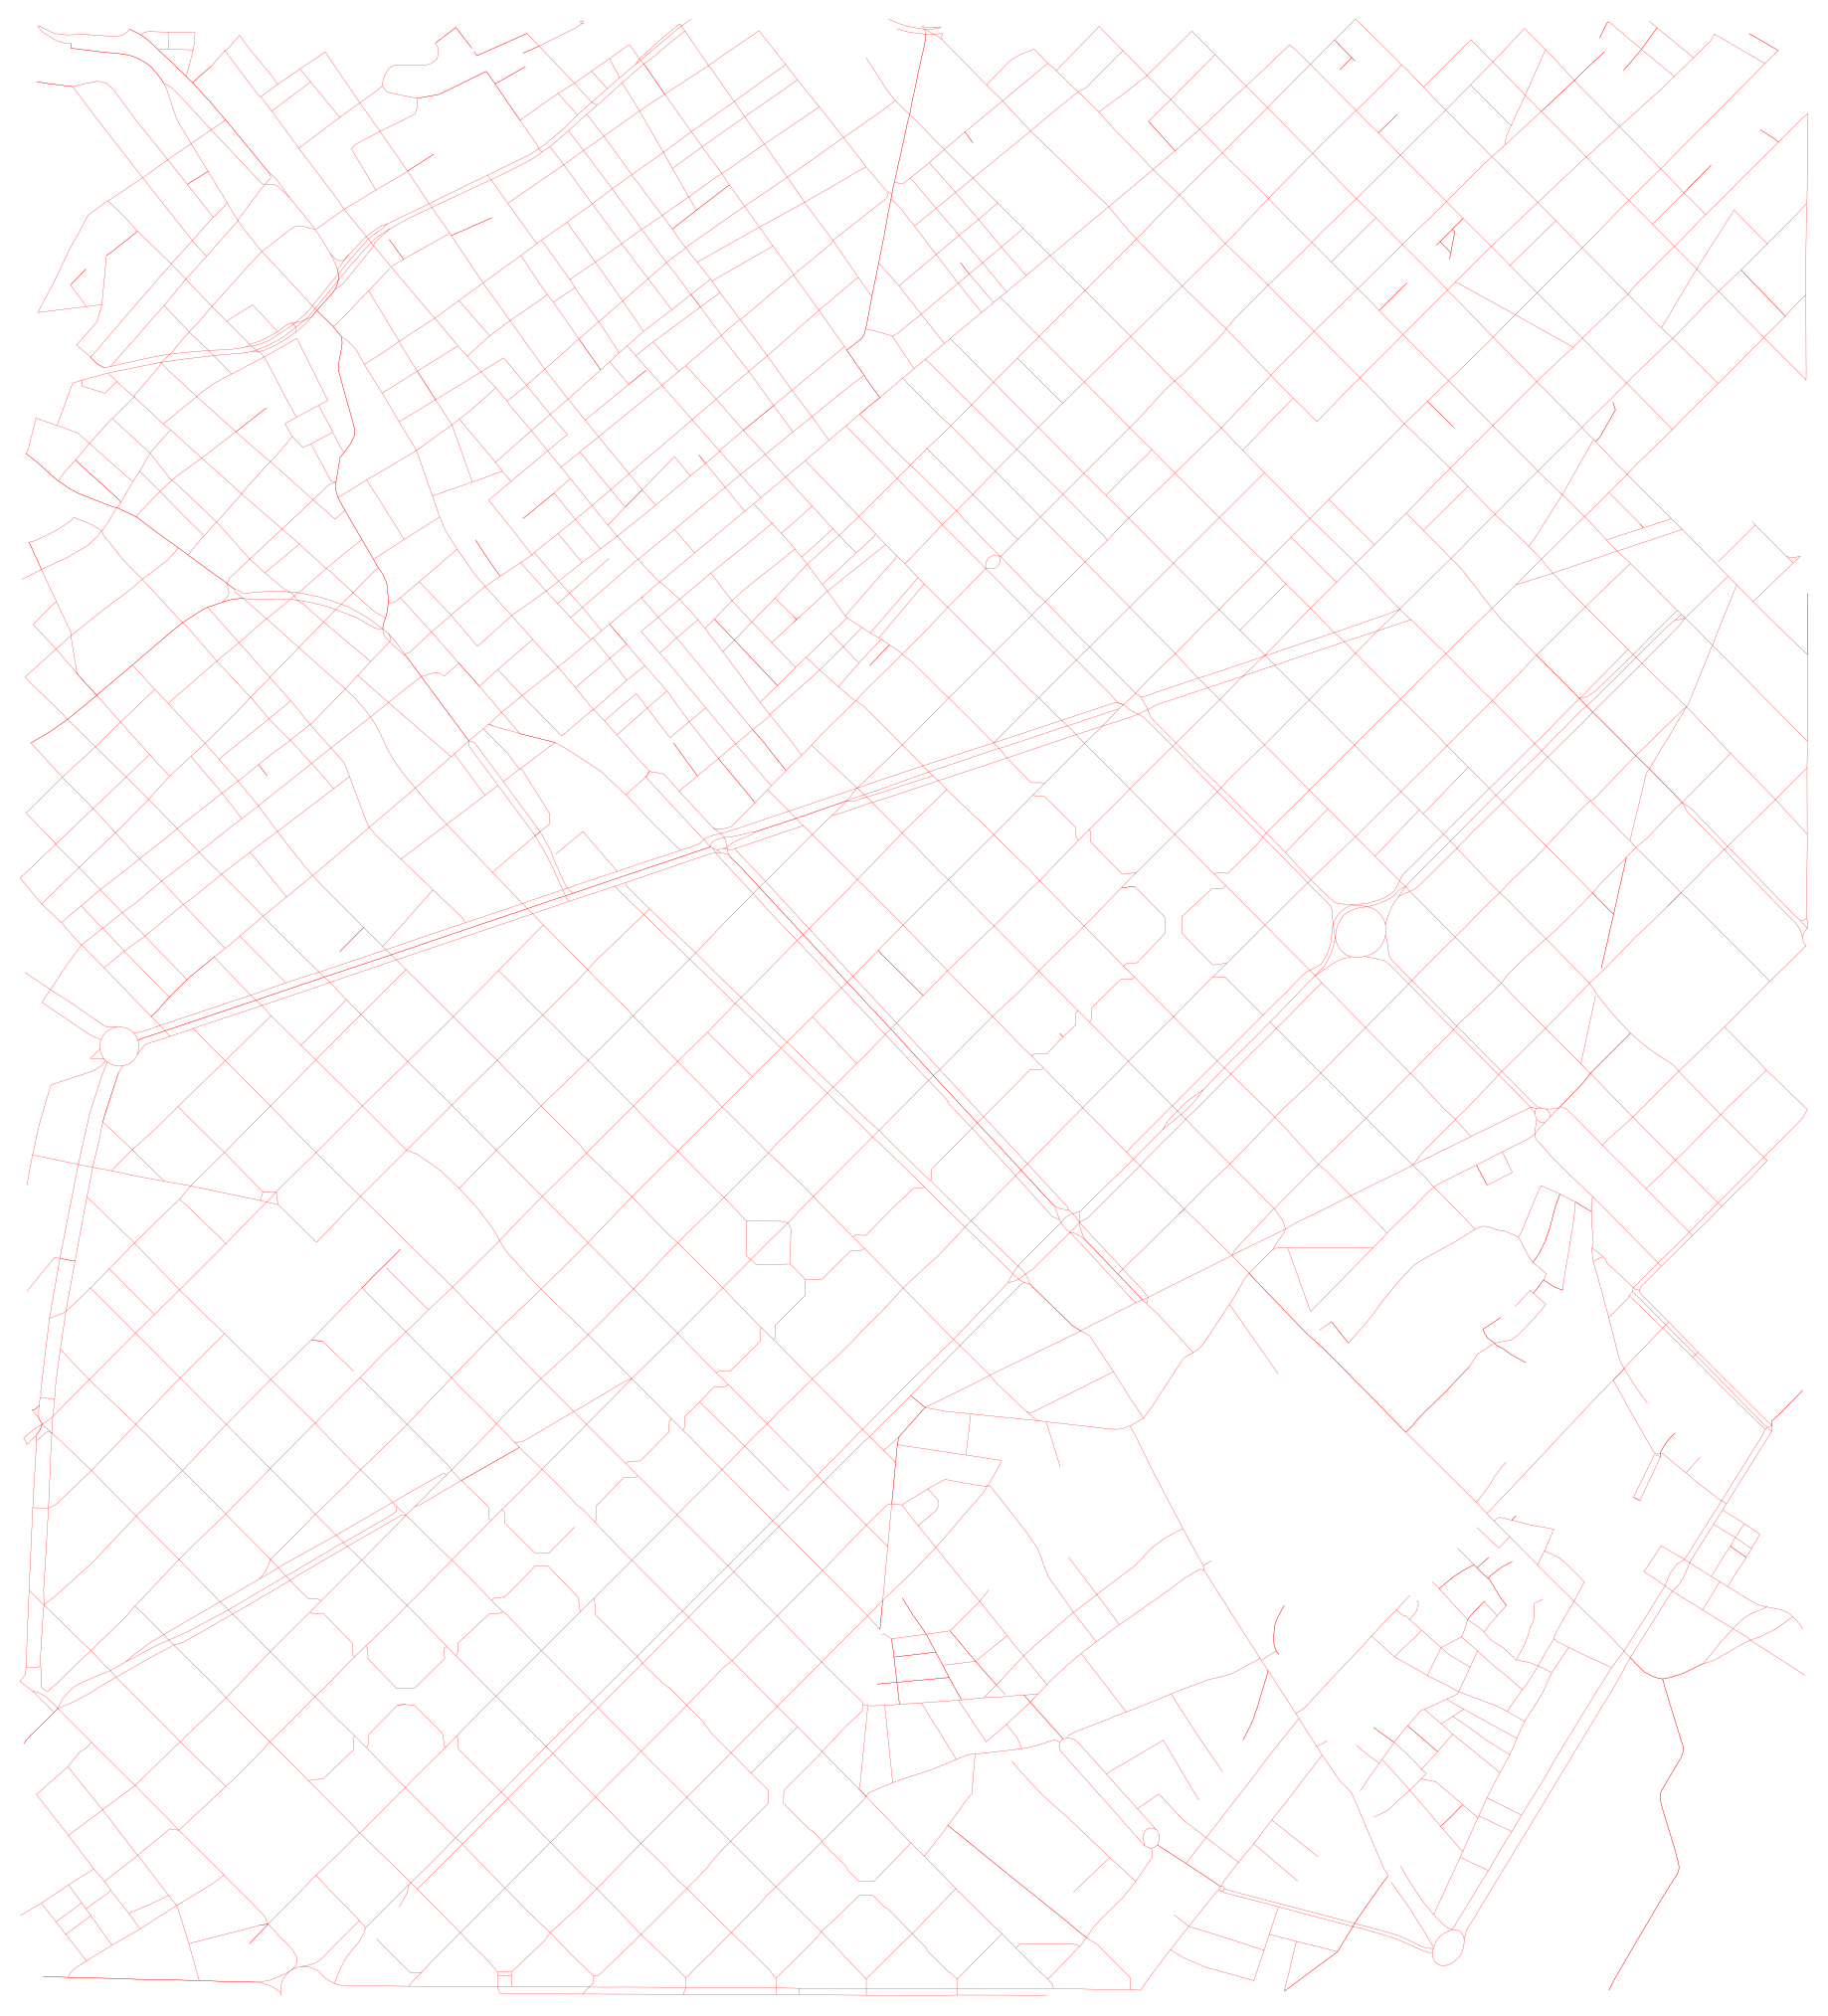

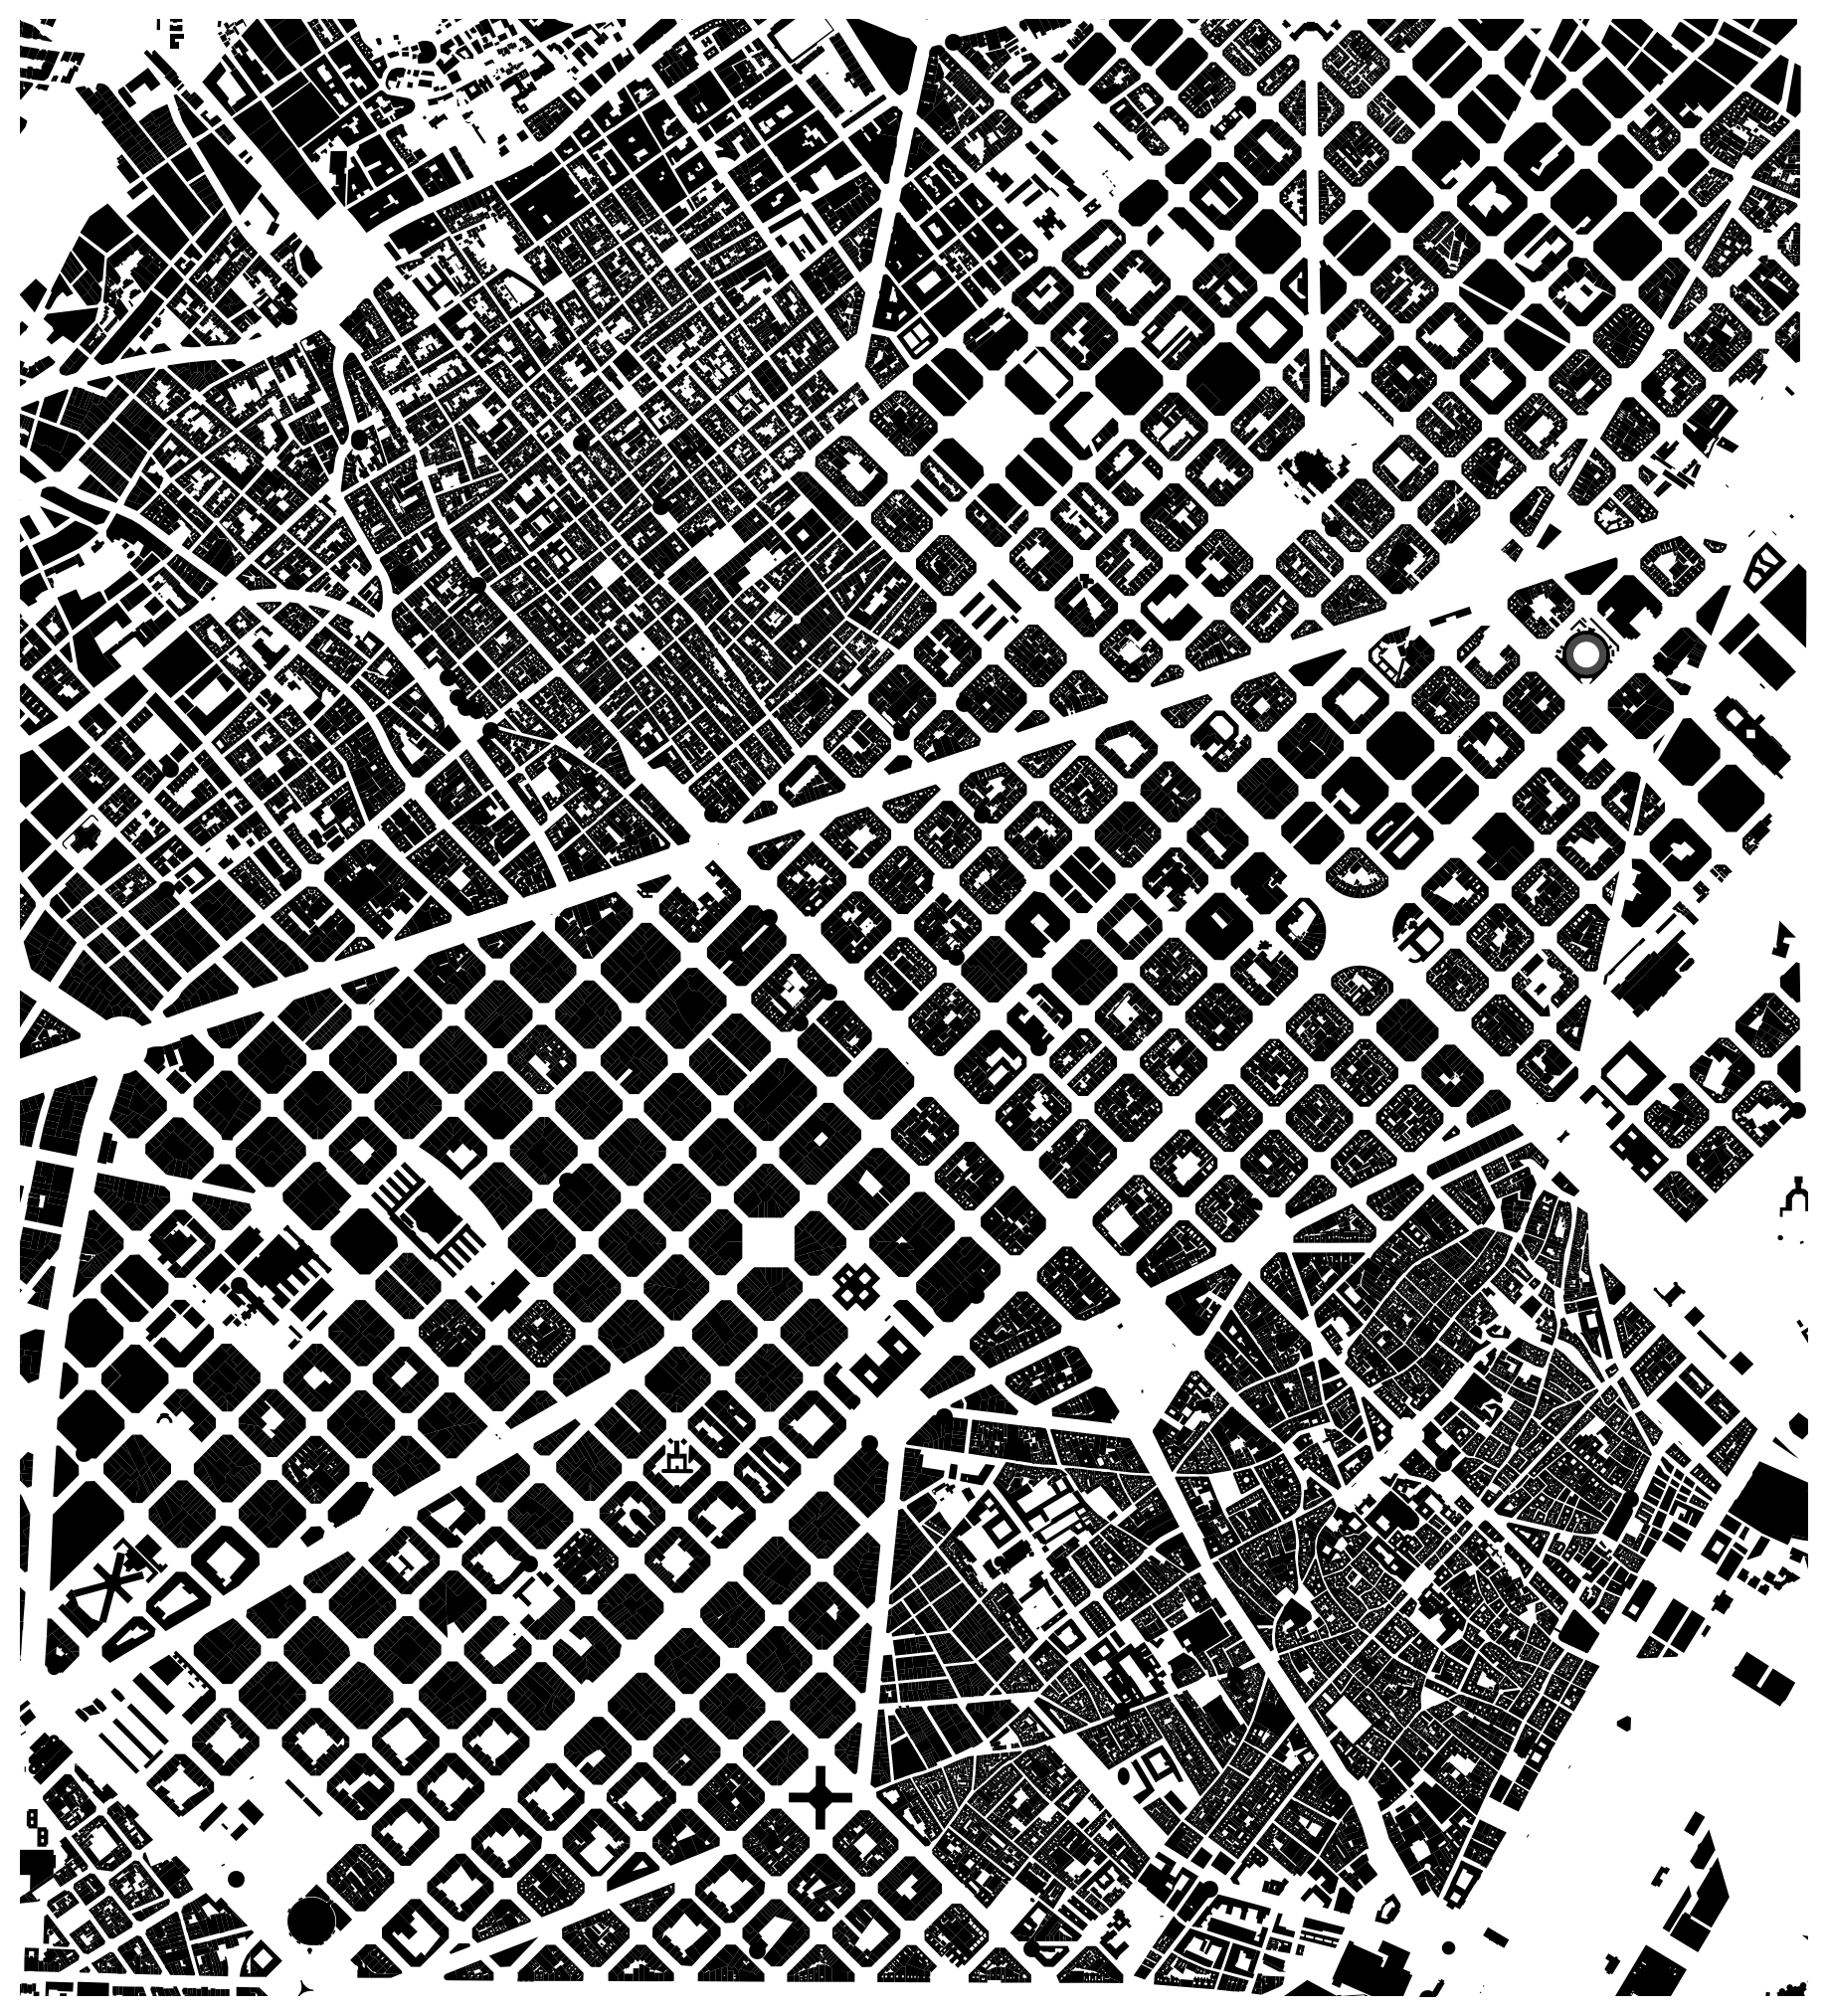

In [35]:
# 🏙️ Manually enter the city you want
city_name = "eixample, barcelona"

print(f"Initializing CityMapProcessor for city: {city_name}")

output_dir = "/buildingfootprints"
street_layout_path = os.path.join(output_dir, f"street/{city_name}_street_network.png")

# Initialize and run the processor
city_processor = CityMapProcessor(city_name)
city_processor.process()
